# Parte 4 - Arquitectura de red neuronal EngageNet

El objetivo es el armado y configuración final de los datos necesarios para luego configurar y entrenar la red para su análisis final

In [1]:
# =============================================
# Configuración de entorno
# =============================================

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.models as models
import copy
import random
import os
import torch.onnx as onnx
from PIL import Image
from collections import Counter
from torchvision import transforms
from torch.utils.data import Subset, DataLoader

# =============================================
# Semilla para reproducibilidad
# =============================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [2]:
# Se trae el último dataset prepocesado
data = pd.read_csv('Dataset/poi_dataset_prepro.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1492 entries, 0 to 1491
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tier             1492 non-null   int64  
 1   locationLon      1492 non-null   float64
 2   locationLat      1492 non-null   float64
 3   xps              1492 non-null   int64  
 4   main_image_path  1492 non-null   object 
 5   eng_cat          1492 non-null   object 
 6   tags_count       1492 non-null   int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 81.7+ KB


## Conversión del target a formato numérico

Se transformó la columna `eng_cat` a tipo `category` para garantizar un **dtype compacto y explícito** antes de mapearla a valores numéricos. Cada clase fue asignada a un índice ordinal: **Low → 0**, **Mid → 1** y **High → 2**, reflejando la progresión natural del engagement (**Low < Mid < High**). El vector resultante, llamado `target`, se almacenó como **int64**, quedando listo para su uso en el entrenamiento de modelos con `nn.CrossEntropyLoss`.

In [3]:
data['eng_cat'] = data['eng_cat'].astype('category') 

In [4]:
# Manteniendo el orden Low < Mid < High
ENG_MAP = {'Low': 0, 'Mid': 1, 'High': 2}
target = data['eng_cat'].map(ENG_MAP).to_numpy('int64')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1492 entries, 0 to 1491
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   tier             1492 non-null   int64   
 1   locationLon      1492 non-null   float64 
 2   locationLat      1492 non-null   float64 
 3   xps              1492 non-null   int64   
 4   main_image_path  1492 non-null   object  
 5   eng_cat          1492 non-null   category
 6   tags_count       1492 non-null   int64   
dtypes: category(1), float64(2), int64(3), object(1)
memory usage: 71.6+ KB


## Carga de representaciones textuales

Se incorporan al notebook las matrices numéricas generadas durante el preprocesado:

| Archivo             | Contenido                                                      | Dimensión          |
|--------------------|----------------------------------------------------------------|------------------|
| `cat_seqs.npy`      | Secuencias de índices de `categories` con *padding*            | (1492 × MAX_LEN)  |
| `desc_vectors.npy`  | Vectores LSA de `shortDescription` (TF-IDF + SVD)              | (1492 × 100)      |


In [6]:
# Cargamos categorías y descripciones
categories = np.load('Others/cat_seqs.npy', allow_pickle=True)
descriptions = np.load('Others/desc_vectors.npy', allow_pickle=True)

In [7]:
print('Categories ->', type(categories), len(categories), 'ej. long:', len(categories[0]))
print('Descriptions ->', descriptions.shape, descriptions.dtype)

Categories -> <class 'numpy.ndarray'> 1492 ej. long: 4
Descriptions -> (1492, 100) float32


### Pipeline de data augmentation para las imágenes
Se define la transformación que llevara cada imágen al entrar en la red neuronal

In [8]:
transform = transforms.Compose([
    transforms.Resize(256, antialias=True),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

## Transformación `process_features`

La función `process_features` centraliza la conversión de cualquier `np.ndarray` a `torch.Tensor`, garantizando el **tipo de dato correcto**: `float32` para features y `long` para etiquetas o clases. Recibe como parámetros el array de entrada (`arr`) y el `dtype` destino (por defecto `torch.float32`, cambiable a `torch.long` para vectores de clase) y devuelve un `torch.Tensor` **contiguo en memoria** listo para alimentar el modelo o combinarse con otras modalidades. Este enfoque asegura **uniformidad**, evitando casteos dispersos y el comportamiento por defecto de NumPy que genera `float64`, proporciona **flexibilidad** al poder usarse tanto para features como para etiquetas y garantiza **compatibilidad con PyTorch**, permitiendo su uso directo en `DataLoader` o en GPU. En la práctica, se emplea `dtype=torch.float32` para features numéricas o *embeddings* y `dtype=torch.long` para etiquetas, llamándose generalmente dentro de `__getitem__()` del `Dataset` para mantener el pipeline limpio y legible.

In [9]:
def process_features(arr, dtype=torch.float32):
    
    arr = np.asarray(arr)  # garantiza ndarray
    if dtype == torch.float32:
        arr = arr.astype(np.float32, copy=False)
    elif dtype == torch.long:
        arr = arr.astype(np.int64,  copy=False)

    return torch.from_numpy(arr).to(dtype).contiguous()

## `POIDataset` – Dataset multimodal personalizado

| Método | Propósito | Detalles clave |
|--------|-----------|----------------|
| `__init__(self, target, image_path, features_df, features_ext1, features_ext2, transform)` | Inicializa y valida todas las modalidades | - Verificación de coherencia mediante `assert`: todos los arrays deben tener la misma longitud `N`. <br> - Conversión a tensores usando `process_features`: <br> &nbsp;&nbsp;· `target` → `torch.long` (etiquetas). <br> &nbsp;&nbsp;· `features_df` → `torch.float32` (metadatos numéricos). <br> &nbsp;&nbsp;· `features_ext1` → `torch.long` (secuencias de tokens). <br> &nbsp;&nbsp;· `features_ext2` → `torch.float32` (embeddings densos). |
| `__len__(self)` | Devuelve `N` | Basado en la longitud de `self.target`. |
| `__getitem__(self, idx)` | Retorna un ejemplo multimodal | - Carga la imagen desde `self.image_path[idx]` usando PIL y aplica `transform` si existe. <br> - Retorna la tupla: `(target, image_tensor, features_df, features_ext1, features_ext2)`. |

### Ventajas de este diseño

- **Multimodalidad clara**: cada modalidad se entrega en su tensor correspondiente, con el dtype adecuado.  
- **Extensible**: añadir nuevas fuentes (por ejemplo, audio o texto adicional) solo requiere un argumento extra y un campo más en la tupla.  
- **Compatibilidad con `DataLoader`**: al devolver únicamente tensores, PyTorch puede agruparlos en lotes automáticamente; se puede implementar un *collate* personalizado si se requiere padding adicional.


In [10]:
class POIDataset(Dataset):
    def __init__(self, target, image_path, features_df ,features_ext1,features_ext2, transfrom=None):
        n = len(target)
        assert all(len(x) == n for x in [image_path, features_df, features_ext1, features_ext2]), \
        "Todos los arrays deben tener la misma longitud"
        
        self.target = process_features(target,dtype=torch.long)
        self.image_path = image_path
        self.features = process_features(features_df)
        self.features_ext1 = process_features(features_ext1, dtype=torch.long)
        self.features_ext2 = process_features(features_ext2)
        self.transform = transfrom
        

    def __len__(self):
        return len(self.target)
        

    def __getitem__(self, idx):
        target = self.target[idx]
        features = self.features[idx]
        features_ext1 = self.features_ext1[idx]
        features_ext2 = self.features_ext2[idx]
        im = Image.open(self.image_path[idx]).convert("RGB")
        if self.transform:
            im = self.transform(im)

        return target, im, features, features_ext1, features_ext2

## Creación del `POIDataset` e inspección de un ejemplo

Se instancia un objeto de la clase `POIDataset` proporcionando las distintas modalidades del dataset —target, rutas de imágenes, features numéricas y embeddings, y secuencias de tokens— junto con transformaciones opcionales para las imágenes. Para una inspección rápida, se obtiene un ejemplo mediante `dataset[idx]`, cuya salida es una tupla con la estructura `(target, image_tensor, features_df, features_ext1, features_ext2)`, lo que permite verificar shapes, dtypes y consistencia entre las distintas modalidades antes de alimentar los datos al `DataLoader` y al modelo.

In [11]:
# Nuevo dataset
dataset = POIDataset(target=target, image_path=data.main_image_path.values, features_df=data.drop(columns=['eng_cat', 'main_image_path']).values,features_ext1=categories,features_ext2=descriptions, transfrom=transform)

# Prueba del output del dataset
lbl = dataset[0][0]
print(lbl, lbl.shape, lbl.dtype, type(lbl))

tensor(1) torch.Size([]) torch.int64 <class 'torch.Tensor'>


In [12]:
# Conteo de cada indice del dataset
cls_counts = Counter(dataset[i][0].item()   
                     for i in range(len(dataset)))
print("Conteo por clase:", cls_counts)

Conteo por clase: Counter({2: 498, 1: 497, 0: 497})


In [13]:
# Verificación más detallada de cada etiqueta
y, img, x_df, x_cat, x_des = dataset[0]

print("Etiqueta           :", y, y.dtype)
print("Imagen             :", img.shape, img.dtype, img.min().item(), img.max().item())
print("Numéricas (x_df)   :", x_df.shape, x_df.dtype)
print("Categorías (x_cat) :", x_cat.shape, x_cat.dtype, "PAD_IDX =", (x_cat==0).sum().item())
print("Descripción (x_des):", x_des.shape, x_des.dtype)

Etiqueta           : tensor(1) torch.int64
Imagen             : torch.Size([3, 224, 224]) torch.float32 -2.1179039478302 -0.27067530155181885
Numéricas (x_df)   : torch.Size([5]) torch.float32
Categorías (x_cat) : torch.Size([4]) torch.int64 PAD_IDX = 0
Descripción (x_des): torch.Size([100]) torch.float32


## Extracción de etiquetas e índices

Se convierte el tensor de etiquetas `LongTensor` de forma `(N,)` a un `np.ndarray` plano mediante `labels = dataset.target.numpy()`, lo que permite realizar operaciones de división (`split`) o muestreo usando utilidades de NumPy o scikit-learn. A continuación, `idx_all = np.arange(len(labels))` genera un vector de índices de `0` a `N-1` que representa todos los ejemplos del dataset, el cual se utiliza para crear particiones de entrenamiento y validación de manera reproducible, ya sea de forma estratificada o aleatoria.

In [14]:
labels = dataset.target.numpy()           # (N,)
idx_all = np.arange(len(labels))

## División estratificada en train / val / test

Se realiza una división estratificada del dataset para mantener la proporción de clases en cada partición: se selecciona el 70% de los índices para el conjunto de entrenamiento, el 15% siguiente para validación y el 15% restante para prueba, aplicando siempre `stratify=labels` para conservar la distribución original de las clases. Esto da como resultado 1 044 ejemplos en train, 224 en val y 224 en test. El uso de un **SEED** garantiza que la partición sea reproducible en ejecuciones futuras, asegurando consistencia en entrenamientos y evaluaciones.


In [15]:
from sklearn.model_selection import train_test_split


idx_train, idx_temp = train_test_split(
    idx_all,
    test_size=0.30,
    stratify=labels,
    random_state = SEED
)
 
idx_val, idx_test = train_test_split(
    idx_temp,
    test_size=0.50,                 
    stratify=labels[idx_temp],
    random_state = SEED
)

print("Train :", len(idx_train), "Val :", len(idx_val), "Test :", len(idx_test))

Train : 1044 Val : 224 Test : 224


In [16]:
def cls_count(idxs):
    return Counter(labels[idxs])

print("Train cls:", cls_count(idx_train))
print("Val   cls:", cls_count(idx_val))
print("Test  cls:", cls_count(idx_test))

Train cls: Counter({np.int64(1): 348, np.int64(2): 348, np.int64(0): 348})
Val   cls: Counter({np.int64(1): 75, np.int64(2): 75, np.int64(0): 74})
Test  cls: Counter({np.int64(2): 75, np.int64(0): 75, np.int64(1): 74})


## Preparación de datasets y dataloaders

1. **Transformaciones de evaluación (`eval_tfms`)**  
   - `Resize(256)` → escalado determinista con *antialias*.  
   - `CenterCrop(224)` → recorte centrado, evitando aleatoriedad en validación/test.  
   - `ToTensor` → normalización con estadísticas de ImageNet (compatible con ResNet).

2. **Dataset de evaluación**  
   - Se crea `dataset_eval` como copia superficial de `dataset` y se le asigna `eval_tfms`.  
   - De esta manera:  
     - `dataset` (train) mantiene el pipeline de *data augmentation*.  
     - `dataset_eval` (val/test) aplica transformaciones deterministas.


In [17]:
eval_tfms = transforms.Compose([
    transforms.Resize(256, antialias=True),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

dataset_eval = copy.copy(dataset)       # copia superficial
dataset_eval.transform = eval_tfms

In [18]:
train_ds = Subset(dataset,      idx_train)   # con augmentación
val_ds   = Subset(dataset_eval, idx_val)     # sin aug.
test_ds  = Subset(dataset_eval, idx_test)    # sin aug.

batch = 64
train_loader = DataLoader(train_ds, batch_size=batch, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch, shuffle=False,
                          num_workers=0, pin_memory=True)

In [19]:
print(train_ds.dataset.transform)  # -> train_tfms  (con augment)
print(val_ds.dataset.transform)    # -> eval_tfms   (sin augment)
print(test_ds.dataset.transform)   # -> eval_tfms   (sin augment)

Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=(-0.1, 0.1))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [20]:
class EngageNet(nn.Module):
    """
    Imagen (3×224×224)   → ResNet-18*                       → 512-d
    Numéricas (5)        → MLP + BatchNorm + Dropout(0.5)   → 64-d
    Categorías (L)       → Embedding(16) + mean-pool        → 16-d
    Descripción (100)    → Linear                           → 128-d
    ----------------------------------------------------------------
    Concatenación (720-d) → LayerNorm → Head FC → 3 clases
    *Primeros 2 stages congelados + Dropout2d(0.2) interno
    """
    def __init__(self, *,
                 n_num=5,
                 desc_dim=100,
                 n_cats=len(set(categories.flatten())) + 1,   # vocab size (+pad)
                 cat_emb_dim=32,
                 n_classes=3,
                 pad_idx=0):
        super().__init__()

        # ------------ 1. Imagen (ResNet-18 con reducción de canales) -----
        res = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # a) hasta layer4 excluida  (salida 512 canales, 7×7)
        cnn_backbone = list(res.children())[:-2]

        # b) proyección 1×1 512→256  + BN + ReLU
        reduction = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        # c) Dropout2d + avg-pool
        cnn_backbone += [reduction, nn.Dropout2d(0.20), res.avgpool]

        self.cnn  = nn.Sequential(*cnn_backbone)   # salida (B,256,1,1)
        cnn_dim   = 256                            # <-- cambia para la fusión

        # d) congelamos conv1, bn1, relu, maxpool, layer1 y layer2 (igual)
        for layer in list(self.cnn)[:7]:
            for p in layer.parameters():
                p.requires_grad = False


        # ------------ 2. Numéricas --------------------------
        self.num_branch = nn.Sequential(
            nn.LayerNorm(n_num),        # alternativa a BatchNorm
            nn.Linear(n_num, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
    
        )
        num_dim = 64

        # ------------ 3. Categorías -------------------------
        self.cat_emb  = nn.Embedding(n_cats, cat_emb_dim, padding_idx=pad_idx)
        self.emb_dp   = nn.Dropout(0.3)
        self.cat_proj = nn.Sequential(
            nn.Linear(cat_emb_dim, cat_emb_dim),
            nn.ReLU()
        )
        cat_dim = cat_emb_dim                               # 32

        # ------------ 4. Descripción ------------------------
        self.desc_branch = nn.Sequential(
            nn.Linear(desc_dim, 128),
            nn.ReLU()
        )
        desc_out = 128

        # ------------ 5. Fusión + Head ----------------------
        fused_dim = cnn_dim + num_dim + cat_dim + desc_out   # 512+64+16+128 = 720
        self.norm = nn.LayerNorm(fused_dim)

        self.head = nn.Sequential(
            nn.Linear(fused_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.45),
            nn.Linear(128, n_classes)
        )

    def forward(self, img, x_num, x_cat, x_desc):
        # 1) imagen → conv
        x_img = self.cnn(img).squeeze(-1).squeeze(-1)        # (B,512)

        # 2) numéricas
        x_num = self.num_branch(x_num)                       # (B,64)

        # 3) categorías → embedding → mean-pool (ignora pads)
        emb = self.cat_emb(x_cat)            # (B,L,D)
        emb = self.emb_dp(emb)
        mask = (x_cat != self.cat_emb.padding_idx).unsqueeze(-1)
        x_cat = (emb * mask).sum(1) / mask.sum(1).clamp(min=1)   # mean-pool
        x_cat = self.cat_proj(x_cat)  # (B,16)

        # 4) descripción
        x_desc = self.desc_branch(x_desc)                    # (B,128)

        # 5) fusión + normalización + clasificación
        x = torch.cat([x_img, x_num, x_cat, x_desc], dim=1)  # (B,720)
        x = self.norm(x)
        return self.head(x)

## **EngageNet – Arquitectura multimodal**

### **Detalles clave**

- **Backbone de imagen:** ResNet-18 con pesos preentrenados en ImageNet; **etapas `conv1` a `layer2` congeladas**.  
- **Reducción de canales:** de **512 → 256** para aligerar la rama de imagen.  
- **Embeddings de categorías:** se aplica **mean-pool**, ignorando tokens `<pad>`.  
- **Normalización:** `LayerNorm` antes del **head** para estabilizar la fusión multimodal.  
- **Parámetros entrenables:** aproximadamente **8 M**, considerando los primeros bloques congelados.  
- **Regularización:** **Dropout alto (0.64)** en la cabeza para prevenir sobreajuste.


In [21]:
# ---------------------------------- CONFIG MEJORADA ---------------------------------- #
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EngageNet(
    n_num    = 5,
    desc_dim = descriptions.shape[1],       # 100
    n_cats   = int(categories.max()) + 1,
    pad_idx  = 0
).to(device)

# ---------- Pesos por clase ---------------------------------------------------------- #
cls_counts  = np.bincount(dataset.target.numpy())
class_wts   = (cls_counts.sum() / (3 * cls_counts)).clip(max=2).astype(np.float32)
criterion   = nn.CrossEntropyLoss(
    weight=torch.tensor(class_wts, device=device),
    label_smoothing=0.1
)

# ---------- Optimizer con LR diferenciado ------------------------------------------- #
base_lr      = 3e-4 # lr estándar
weight_decay = 1e-4 # weight estándar

cnn_params, new_params = [], []
for n, p in model.named_parameters():
    if p.requires_grad:
        (cnn_params if n.startswith("cnn") else new_params).append(p)

optimizer = torch.optim.AdamW(
    [
        {"params": cnn_params, "lr": base_lr * 0.01},
        {"params": new_params, "lr": base_lr}
    ],
    weight_decay=weight_decay
)

# ---------- Scheduler (con min_lr) --------------------------------------------------- #
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=2, factor=0.5, min_lr=1e-6
)

# ---------- AMP ---------------------------------------------------------------------- #
scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")

C:\Users\lugod\AppData\Local\Temp\ipykernel_19816\2070897644.py:42: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


C:\Users\lugod\AppData\Local\Temp\ipykernel_19816\3380148197.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):


Ep 01 | train 1.0825/41.57% | val 0.9876/58.48% | LR 3.00e-04
Ep 02 | train 0.9909/53.54% | val 0.8874/69.64% | LR 3.00e-04
Ep 03 | train 0.8949/64.18% | val 0.8022/74.55% | LR 3.00e-04
Ep 04 | train 0.8166/70.02% | val 0.7364/77.68% | LR 3.00e-04
Ep 05 | train 0.7606/72.70% | val 0.7003/78.12% | LR 3.00e-04
Ep 06 | train 0.7122/76.05% | val 0.6432/81.70% | LR 3.00e-04
Ep 07 | train 0.6700/78.64% | val 0.6546/83.04% | LR 3.00e-04
Ep 08 | train 0.6572/79.31% | val 0.6190/83.93% | LR 3.00e-04
Ep 09 | train 0.6264/81.32% | val 0.6015/84.38% | LR 3.00e-04
Ep 10 | train 0.6106/82.18% | val 0.6286/83.93% | LR 3.00e-04
Ep 11 | train 0.6024/83.33% | val 0.6089/84.82% | LR 3.00e-04
Ep 12 | train 0.5923/84.67% | val 0.6186/84.38% | LR 1.50e-04
Ep 13 | train 0.6021/83.91% | val 0.6010/84.82% | LR 1.50e-04
⏹️  Early stopping triggered


C:\Users\lugod\AppData\Local\Temp\ipykernel_19816\3380148197.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=device.type == "cuda"):


              precision    recall  f1-score   support

           0       1.00      0.92      0.96        75
           1       0.89      0.66      0.76        74
           2       0.73      0.97      0.83        75

    accuracy                           0.85       224
   macro avg       0.87      0.85      0.85       224
weighted avg       0.87      0.85      0.85       224



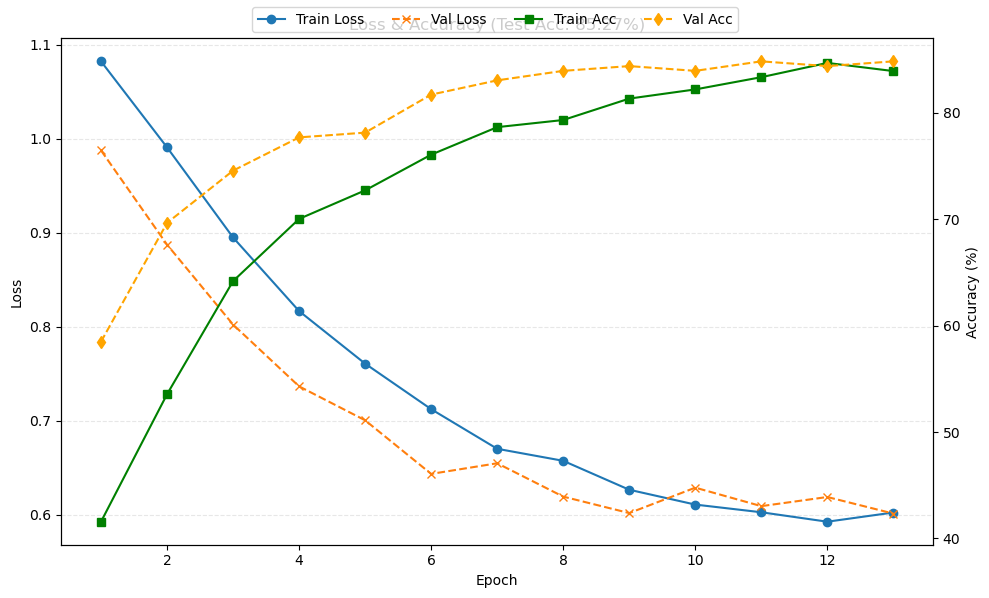

In [22]:
from sklearn.metrics import classification_report


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for y, img, x_df, x_cat, x_desc in loader:
        img, x_df, x_cat, x_desc, y = \
            img.to(device), x_df.to(device), x_cat.to(device), x_desc.to(device), y.to(device)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
            out  = model(img, x_df, x_cat, x_desc)
            loss = criterion(out, y)

        if train:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        running_loss += loss.item() * y.size(0)
        correct      += (out.argmax(1) == y).sum().item()
        total        += y.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total          # proporción (0-1)
    return epoch_loss, epoch_acc
# ------------------------------------------------------------------



n_epochs   = 50
patience   = 4
best_val   = float("inf")
wait       = 0
history    = {"tr_loss":[], "val_loss":[], "tr_acc":[], "val_acc":[]}

for epoch in range(1, n_epochs + 1):
    tr_loss, tr_ac = run_epoch(train_loader, train=True)
    vl_loss, vl_ac = run_epoch(val_loader,   train=False)
    scheduler.step(vl_loss)

    history["tr_loss"].append(tr_loss); history["tr_acc"].append(tr_ac*100)
    history["val_loss"].append(vl_loss); history["val_acc"].append(vl_ac*100)

    lr_now = optimizer.param_groups[1]["lr"]
    print(f"Ep {epoch:02d} | "
          f"train {tr_loss:.4f}/{tr_ac*100:.2f}% | "
          f"val {vl_loss:.4f}/{vl_ac*100:.2f}% | "
          f"LR {lr_now:.2e}")

    # ----- early stopping -----
    if vl_loss < best_val - 1e-3:
        best_val, wait = vl_loss, 0
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}
    else:
        wait += 1
        if wait == patience:
            print("⏹️  Early stopping triggered")
            break

model.load_state_dict(best_state)
model.to(device).eval()

y_true, y_pred = [], []
with torch.no_grad(), torch.cuda.amp.autocast(enabled=device.type == "cuda"):
    for y, img, x_df, x_cat, x_desc in test_loader:
        img, x_df, x_cat, x_desc = \
            img.to(device), x_df.to(device), x_cat.to(device), x_desc.to(device)
        out = model(img, x_df, x_cat, x_desc)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(out.argmax(1).cpu().numpy())

y_true = np.array(y_true); y_pred = np.array(y_pred)
print(classification_report(y_true, y_pred, digits=2))


epochs = range(1, len(history["tr_loss"]) + 1)
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(epochs, history["tr_loss"], "o-", label="Train Loss")
ax1.plot(epochs, history["val_loss"], "x--", label="Val Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.grid(True, axis="y", linestyle="--", alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs, history["tr_acc"], "s-", label="Train Acc", color="green")
ax2.plot(epochs, history["val_acc"], "d--", label="Val Acc",   color="orange")
ax2.set_ylabel("Accuracy (%)")

handles, labels_ = [], []
for ax in (ax1, ax2):
    h, l = ax.get_legend_handles_labels()
    handles += h; labels_ += l
fig.legend(handles, labels_, loc="upper center", ncol=4)

test_accuracy = (y_pred == y_true).mean() * 100
plt.title(f"Loss & Accuracy (Test Acc: {test_accuracy:.2f}%)")
plt.tight_layout(); plt.show()

In [23]:
# Resultados en test y accuracy
test_loss, test_acc = run_epoch(test_loader, train=False)
print(f"🔍  Test  loss {test_loss:.4f}  |  acc {test_acc:.3f}")

C:\Users\lugod\AppData\Local\Temp\ipykernel_19816\3380148197.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):


🔍  Test  loss 0.6074  |  acc 0.853


In [24]:
# Optuna – configurador para afinar el nuevo EngageNet

import optuna
from optuna.pruners import PatientPruner


# ---------- 1. Espacio de búsqueda ---------------------------------
def build_model(trial):
    # hiperparámetros que Optuna ajustará
    lr          = trial.suggest_loguniform("lr", 5e-5, 5e-4)
    wd          = trial.suggest_loguniform("weight_decay", 1e-5, 1e-3)
    drop_head   = trial.suggest_float("dropout_head", 0.4, 0.7)
    drop2d      = trial.suggest_float("dropout2d", 0.2, 0.4)
    cat_emb_dim = trial.suggest_categorical("cat_emb_dim", [8, 16, 32])

    # ---- construimos el modelo con esos parámetros ----
    model = EngageNet(
        n_num       = 5,
        desc_dim    = descriptions.shape[1],
        n_cats      = int(categories.max()) + 1,
        pad_idx     = 0,
        cat_emb_dim = cat_emb_dim
    ).to(device)

    # ajustar dropout2d y cabeza
    model.cnn[-2].p = drop2d
    model.head[2].p = drop_head

    # congelamos conv1-layer2
    for layer in list(model.cnn)[:7]:
        for p in layer.parameters():
            p.requires_grad = False

    # ---------- optimizer con LR diferenciada ----------
    cnn_params, new_params = [], []
    for name, p in model.named_parameters():
        if p.requires_grad:
            (cnn_params if name.startswith("cnn") else new_params).append(p)

    optimizer = torch.optim.AdamW(
        [
            {"params": cnn_params, "lr": lr * 0.01},
            {"params": new_params, "lr": lr}
        ],
        weight_decay=wd
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=1, factor=0.5, min_lr=1e-6
    )

    return model, optimizer, scheduler


# ---------- 2. Función objetivo -----------------------------------
def objective(trial):
    model, optimizer, scheduler = build_model(trial)

    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(class_wts, device=device),
        label_smoothing=0.1
    )

    scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")

    best_val = float("inf")

    for epoch in range(12):  # 10 épocas por trial

        # --- TRAIN ---
        model.train()
        for y, img, x_df, x_cat, x_desc in train_loader:
            img, x_df, x_cat, x_desc, y = (
                img.to(device),
                x_df.to(device),
                x_cat.to(device),
                x_desc.to(device),
                y.to(device)
            )

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
                out = model(img, x_df, x_cat, x_desc)
                loss = criterion(out, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        # --- VALID ---
        model.eval()
        val_loss, total = 0.0, 0

        with torch.no_grad(), torch.cuda.amp.autocast(enabled=device.type == "cuda"):
            for y, img, x_df, x_cat, x_desc in val_loader:
                img, x_df, x_cat, x_desc, y = (
                    img.to(device),
                    x_df.to(device),
                    x_cat.to(device),
                    x_desc.to(device),
                    y.to(device)
                )

                out = model(img, x_df, x_cat, x_desc)
                loss = criterion(out, y)

                val_loss += loss.item() * y.size(0)
                total += y.size(0)

        val_loss /= total
        scheduler.step(val_loss)

        # --- pruning ---
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        best_val = min(best_val, val_loss)

    return best_val


# ---------- 3. Crear estudio y lanzar -----------------------------
pruner = PatientPruner(optuna.pruners.MedianPruner(), patience=3)

study = optuna.create_study(
    direction="minimize",
    pruner=pruner,
    storage="sqlite:///overnight_optuna.db",
    load_if_exists=True
)

study.optimize(
    objective,
    n_trials=500, # Número de combinaciones
    timeout=5 * 60 * 60,  # 5 horas de pruebas máximo
    gc_after_trial=True
)

print("🟢 Best trial:")
print("  val_loss :", study.best_value)
print("  params   :", study.best_params)


C:\Users\lugod\anaconda3\envs\env_dl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\lugod\AppData\Local\Temp\ipykernel_19816\243083538.py:125: ExperimentalWarning: PatientPruner is experimental (supported from v2.8.0). The interface can change in the future.
  pruner = PatientPruner(optuna.pruners.MedianPruner(), patience=3)
[I 2026-02-03 00:37:16,967] A new study created in RDB with name: no-name-c496ce96-0c4d-499a-8dc1-73559b451008
C:\Users\lugod\AppData\Local\Temp\ipykernel_19816\243083538.py:10: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr          = trial.suggest_loguniform("lr", 5e-5, 5e-4)
C:\Users\lugod\AppData\Local\Temp\ipykernel_19

🟢 Best trial:
  val_loss : 0.5892687439918518
  params   : {'lr': 0.0004256692528182707, 'weight_decay': 2.1838243143097565e-05, 'dropout_head': 0.6530787078855208, 'dropout2d': 0.3164391226790605, 'cat_emb_dim': 32}


In [25]:
# --- 0) asegurarse de que la carpeta exista ---
os.makedirs("Others", exist_ok=True)

# --- 1) guardar sólo los pesos (state_dict) ---
# Asegúrate de que best_state contiene los pesos del mejor trial
torch.save(best_state, "Others/engagenet_best.pt")          # ~15-20 MB

# --- 2) cargar los pesos en el modelo y ponerlo en eval ---
model.load_state_dict(best_state)
model.eval()

# --- 3) dummy inputs con las shapes correctas ---
B = 1  # batch=1 basta para exportar
dummy_img   = torch.randn(B, 3, 224, 224, device=device)      # imagen
dummy_num   = torch.randn(B, 5, device=device)                # numéricas
dummy_cat   = torch.randint(0, model.cat_emb.num_embeddings, (B, 10), device=device)  # L=10 tokens
dummy_desc  = torch.randn(B, 100, device=device)              # vector descripción

# --- 4) exportar a ONNX ---
onnx_path = "Others/engagenet.onnx"
onnx.export(
    model.cpu(),  # modelo
    (dummy_img.cpu(), dummy_num.cpu(), dummy_cat.cpu(), dummy_desc.cpu()),  # entradas
    onnx_path,
    input_names  = ["image", "numeric", "category", "desc"],
    output_names = ["logits"],
    opset_version=17,
    dynamic_axes = {
        "image"   : {0: "batch"},
        "numeric" : {0: "batch"},
        "category": {0: "batch"},
        "desc"    : {0: "batch"},
        "logits"  : {0: "batch"}
    },
    do_constant_folding=True
)

print("✅ Modelo guardado como:\n  • Others/engagenet_best.pt\n  • Others/engagenet.onnx")

✅ Modelo guardado como:
  • Others/engagenet_best.pt
  • Others/engagenet.onnx


In [26]:
# Prueba con onnxruntime
import onnxruntime as ort

In [27]:
# --- Crear sesión ONNX ---
sess = ort.InferenceSession("Others/engagenet.onnx")

y_true, y_pred = [], []

# Longitud que ONNX espera para categorías
L = 10

# --- Iterar sobre test_loader ---
for y, img, x_df, x_cat, x_desc in test_loader:

    # Convertir tensores PyTorch a numpy y tipos correctos
    img_np   = img.cpu().numpy().astype(np.float32)
    x_df_np  = x_df.cpu().numpy().astype(np.float32)
    x_desc_np= x_desc.cpu().numpy().astype(np.float32)

    # Padding de categorías a L tokens
    batch_size = x_cat.shape[0]
    x_cat_np = np.zeros((batch_size, L), dtype=np.int64)
    length = min(x_cat.shape[1], L)
    x_cat_np[:, :length] = x_cat[:, :length].cpu().numpy().astype(np.int64)

    # Crear diccionario de inputs
    inputs = {
        "image": img_np,
        "numeric": x_df_np,
        "category": x_cat_np,
        "desc": x_desc_np
    }

    # --- Inferencia ---
    outputs = sess.run(None, inputs)
    logits = outputs[0]
    pred_classes = np.argmax(logits, axis=1)

    # Guardar resultados
    y_true.extend(y.numpy())
    y_pred.extend(pred_classes)

# --- Métrica ---
y_true = np.array(y_true)
y_pred = np.array(y_pred)
accuracy = (y_true == y_pred).mean() * 100
print(f"Test Accuracy ONNX: {accuracy:.2f}%")

Test Accuracy ONNX: 85.27%


## Resultados finales del modelo EngageNet

### Métricas globales

| Métrica | Valor |
|------|------|
| Accuracy (test) | **85 %** |
| Macro-F1 | **0.85** |
| Soporte total | **224 muestras** |

---

### Desglose por clase (conjunto de test)

| Clase | Precisión | Recall | F1-score | Soporte |
|------|----------|--------|----------|---------|
| Low (0) | 1.00 | 0.92 | 0.96 | 75 |
| Mid (1) | 0.89 | 0.66 | 0.76 | 74 |
| High (2) | 0.73 | 0.97 | 0.83 | 75 |
| **Macro-avg** | **0.87** | **0.85** | **0.85** | 224 |

---

### Evolución durante el entrenamiento

**Pérdida (Loss)**  
La pérdida de entrenamiento y validación mostró una reducción progresiva y estable a lo largo de las épocas, indicando que el modelo fue capaz de aprender patrones relevantes sin incurrir en sobreajuste significativo.

**Exactitud (Accuracy)**  
La accuracy de validación se mantuvo consistentemente alineada con la de entrenamiento, alcanzando valores cercanos al 85 % en el conjunto de test. La ausencia de divergencias claras entre ambas curvas sugiere un buen equilibrio entre capacidad de aprendizaje y generalización.

**Convergencia**  
El modelo mostró señales claras de convergencia tras las últimas épocas, con métricas estabilizadas y sin fluctuaciones abruptas, lo que indica que el entrenamiento fue adecuado y suficiente para la complejidad del problema.

---

## Conclusión e interpretación de resultados

El modelo **EngageNet**, basado en una arquitectura multimodal que combina información visual y metadatos estructurados, alcanza un **85 % de accuracy global** y un **Macro-F1 de 0.85**, lo que evidencia un rendimiento sólido y equilibrado en un escenario de clasificación multiclase.

Desde un punto de vista **global**, el modelo demuestra una buena capacidad para discriminar entre niveles de engagement, capturando tanto señales visuales como contextuales de los puntos de interés (POIs). El alto valor del Macro-F1 indica que el rendimiento es consistente entre clases y no está dominado únicamente por una categoría específica.

A nivel **por clase**, se observan comportamientos diferenciados:

- La clase **Low (0)** presenta un rendimiento casi perfecto, con una precisión del 100 % y un F1-score de 0.96. Esto sugiere que el modelo identifica de forma muy fiable los POIs con bajo engagement.
- La clase **High (2)** muestra un **recall muy elevado (0.97)**, lo que indica que el modelo es especialmente eficaz detectando POIs con alto engagement, aunque con una ligera penalización en precisión. En términos prácticos, el modelo prioriza no perder POIs de alto valor, aun a costa de algunos falsos positivos.
- La clase **Mid (1)** continúa siendo la más desafiante, con un recall más bajo (0.66). Este comportamiento es esperable, ya que representa una categoría intermedia con fronteras menos claras y características que pueden solaparse tanto con Low como con High.

Esto implica que EngageNet funciona muy bien identificando los extremos (bajo y alto engagement), mientras que le resulta más difícil clasificar correctamente los casos intermedios.

---

### Pasos a seguir y posibles mejoras

Como líneas de trabajo futuras, se proponen:

1. **Refinar la clase Mid**, explorando estrategias como reponderación de clases, focal loss o enriquecimiento de los metadatos.
2. **Análisis de errores**, revisando ejemplos mal clasificados para identificar patrones comunes o carencias de información.
3. **Ajustes finos del modelo multimodal**, evaluando mayor capacidad en la rama tabular o mecanismos de atención en la fusión.
4. **Validación externa**, aplicando EngageNet a datos no vistos de otros contextos o regiones para evaluar su robustez.

En conjunto, los resultados obtenidos confirman que el enfoque multimodal es adecuado para el problema planteado y que **EngageNet constituye una base sólida y funcional**, con margen claro de mejora en escenarios más complejos y realistas.

